# Task 1 — Exploratory Data Analysis
## AlphaCare Insurance Solutions (ACIS) — Risk Analytics
**10 Academy KAIM9 | Week 3 | Branch: task-1**

**Dataset:** 10,000 Ethiopian auto-insurance policies  
**Key columns:** TotalPremium, TotalClaims, Province, VehicleType, AutoMake, Gender, ZipCode, TransactionDate

---
### Guiding Questions
1. What is the overall Loss Ratio? How does it vary by Province, VehicleType, and Gender?
2. What are the distributions of key financial variables? Are there outliers?
3. Are there temporal trends in claim frequency or severity?
4. Which vehicle makes are associated with the highest and lowest claim amounts?
---

## 0. Imports & Configuration

In [12]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_raw, cast_types, assess_missing, handle_missing, engineer_features
from src.eda_utils import (
    summarise_numerics, plot_numeric_distributions, plot_categorical_bars,
    plot_missing_values, plot_premium_vs_claims, plot_correlation_matrix,
    plot_province_metrics, plot_boxplots, plot_loss_ratio_heatmap,
    plot_top_vehicle_makes, plot_temporal_trends, plot_gender_risk
)

os.makedirs('../reports/figures', exist_ok=True)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.4f}'.format)
print('Setup complete.')

Setup complete.


---
## 1. Load Raw Data

In [13]:
RAW_PATH = '../data/insurance_data.csv'
df_raw = load_raw(RAW_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

INFO: Loading raw data from ../data/insurance_data.csv ...
INFO: Loaded 10,000 rows x 21 columns.


Shape: 10,000 rows x 21 columns


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,1,False,0.0000,2346,0.0000,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,True,"9,883.0000",2334,"9,883.0000",Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,1,False,0.0000,1697,0.0000,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,0,True,"12,134.0000",2370,"12,134.0000",Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,4,False,0.0000,2582,0.0000,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [14]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  

---
## 2. Data Summarisation
### 2.1 Cast Column Types

In [15]:
df = cast_types(df_raw)
type_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'sample_value': [df[c].dropna().iloc[0] if df[c].notna().any() else 'NaN' for c in df.columns]
})
type_summary

INFO: Column types cast successfully.


,dtype,n_unique,sample_value
CustomerID,category,10000,AC-100000
Age,int64,58,56
Gender,category,2,Male
Province,category,5,Addis Ababa
VehicleType,category,4,Sedan
AnnualIncome,int64,9545,147270
RiskScore,int64,78,61
AnnualPremium,int64,2532,2346
Deductible,int64,4,500
NCD,int64,6,30


### 2.2 Descriptive Statistics — Numerical Features

In [16]:
NUMERIC_COLS = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium',
                'Deductible', 'NCD', 'PastClaims', 'ClaimAmount',
                'TotalPremium', 'TotalClaims', 'CustomValueEstimate']

stat_table = summarise_numerics(df, NUMERIC_COLS)
stat_table

,count,mean,std,min,25%,50%,75%,95%,max,skewness,kurtosis
Age,"10,000.0000",46.6835,16.7180,18.0000,32.0000,46.0000,61.0000,73.0000,75.0000,0.0004,-1.1951
AnnualIncome,"10,000.0000","79,201.9739","33,039.9398","17,202.0000","56,105.0000","72,942.0000","95,092.0000","140,968.2500","376,916.0000",1.3970,3.9057
RiskScore,"10,000.0000",58.1400,14.2675,15.0000,48.0000,57.0000,67.0000,85.0000,95.0000,0.3766,-0.1709
AnnualPremium,"10,000.0000","2,488.1279",735.6745,951.0000,"2,028.0000","2,307.0000","2,676.0000","4,348.0000","5,105.0000",1.5757,2.2702
Deductible,"10,000.0000",751.7000,500.5094,250.0000,500.0000,500.0000,"1,000.0000","2,000.0000","2,000.0000",1.3518,1.1442
NCD,"10,000.0000",20.9350,14.5491,0.0000,10.0000,20.0000,30.0000,40.0000,50.0000,-0.0622,-1.1195
PastClaims,"10,000.0000",1.0642,1.0519,0.0000,0.0000,1.0000,2.0000,3.0000,5.0000,1.0314,0.9970
ClaimAmount,"10,000.0000","1,314.1885","3,921.8649",0.0000,0.0000,0.0000,0.0000,"9,200.7500","49,623.0000",4.3675,25.8406
TotalPremium,"10,000.0000","2,488.1279",735.6745,951.0000,"2,028.0000","2,307.0000","2,676.0000","4,348.0000","5,105.0000",1.5757,2.2702
TotalClaims,"10,000.0000","1,314.1885","3,921.8649",0.0000,0.0000,0.0000,0.0000,"9,200.7500","49,623.0000",4.3675,25.8406


**Observations:**
- `TotalClaims` is zero-inflated — most policies have no claim; a few drive the mean up.
- `CustomValueEstimate` shows wide spread — vehicle value ranges from cheap to luxury.
- `RiskScore` ranges 0–100 and should correlate with LossRatio.
- `NCD` (No Claims Discount) is 0 for high-risk customers.

---
## 3. Data Quality Assessment

In [17]:
missing_summary = assess_missing(df)
if missing_summary.empty:
    print('No missing values — dataset is complete.')
else:
    print(f'{len(missing_summary)} columns have missing values.')
    display(missing_summary)
    fig = plot_missing_values(df)
    if fig:
        plt.savefig('../reports/figures/00_missing_values.png', bbox_inches='tight', dpi=150)
        plt.show()

No missing values — dataset is complete.


In [18]:
df_clean = handle_missing(df)
df_clean = engineer_features(df_clean)
print(f'Clean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
df_clean[['TotalPremium','TotalClaims','LossRatio','Margin','HasClaim']].head()

INFO: Missing values handled.
INFO: Feature engineering complete (LossRatio, Margin, HasClaim).


Clean shape: 10,000 rows x 26 columns


,TotalPremium,TotalClaims,LossRatio,Margin,HasClaim
0,2346,0.0000,0.0000,"2,346.0000",0
1,2334,"9,883.0000",4.2344,"-7,549.0000",1
2,1697,0.0000,0.0000,"1,697.0000",0
3,2370,"12,134.0000",5.1198,"-9,764.0000",1
4,2582,0.0000,0.0000,"2,582.0000",0


**Missing-Value Strategy:**

| Condition | Action |
|-----------|--------|
| > 50% missing | Drop column |
| Numerical ≤ 50% missing | Fill with median |
| Categorical ≤ 50% missing | Fill with mode |
| TotalPremium = 0 | Exclude from LossRatio calc |

---
## 4. Univariate Analysis
### 4.1 Numerical Distributions

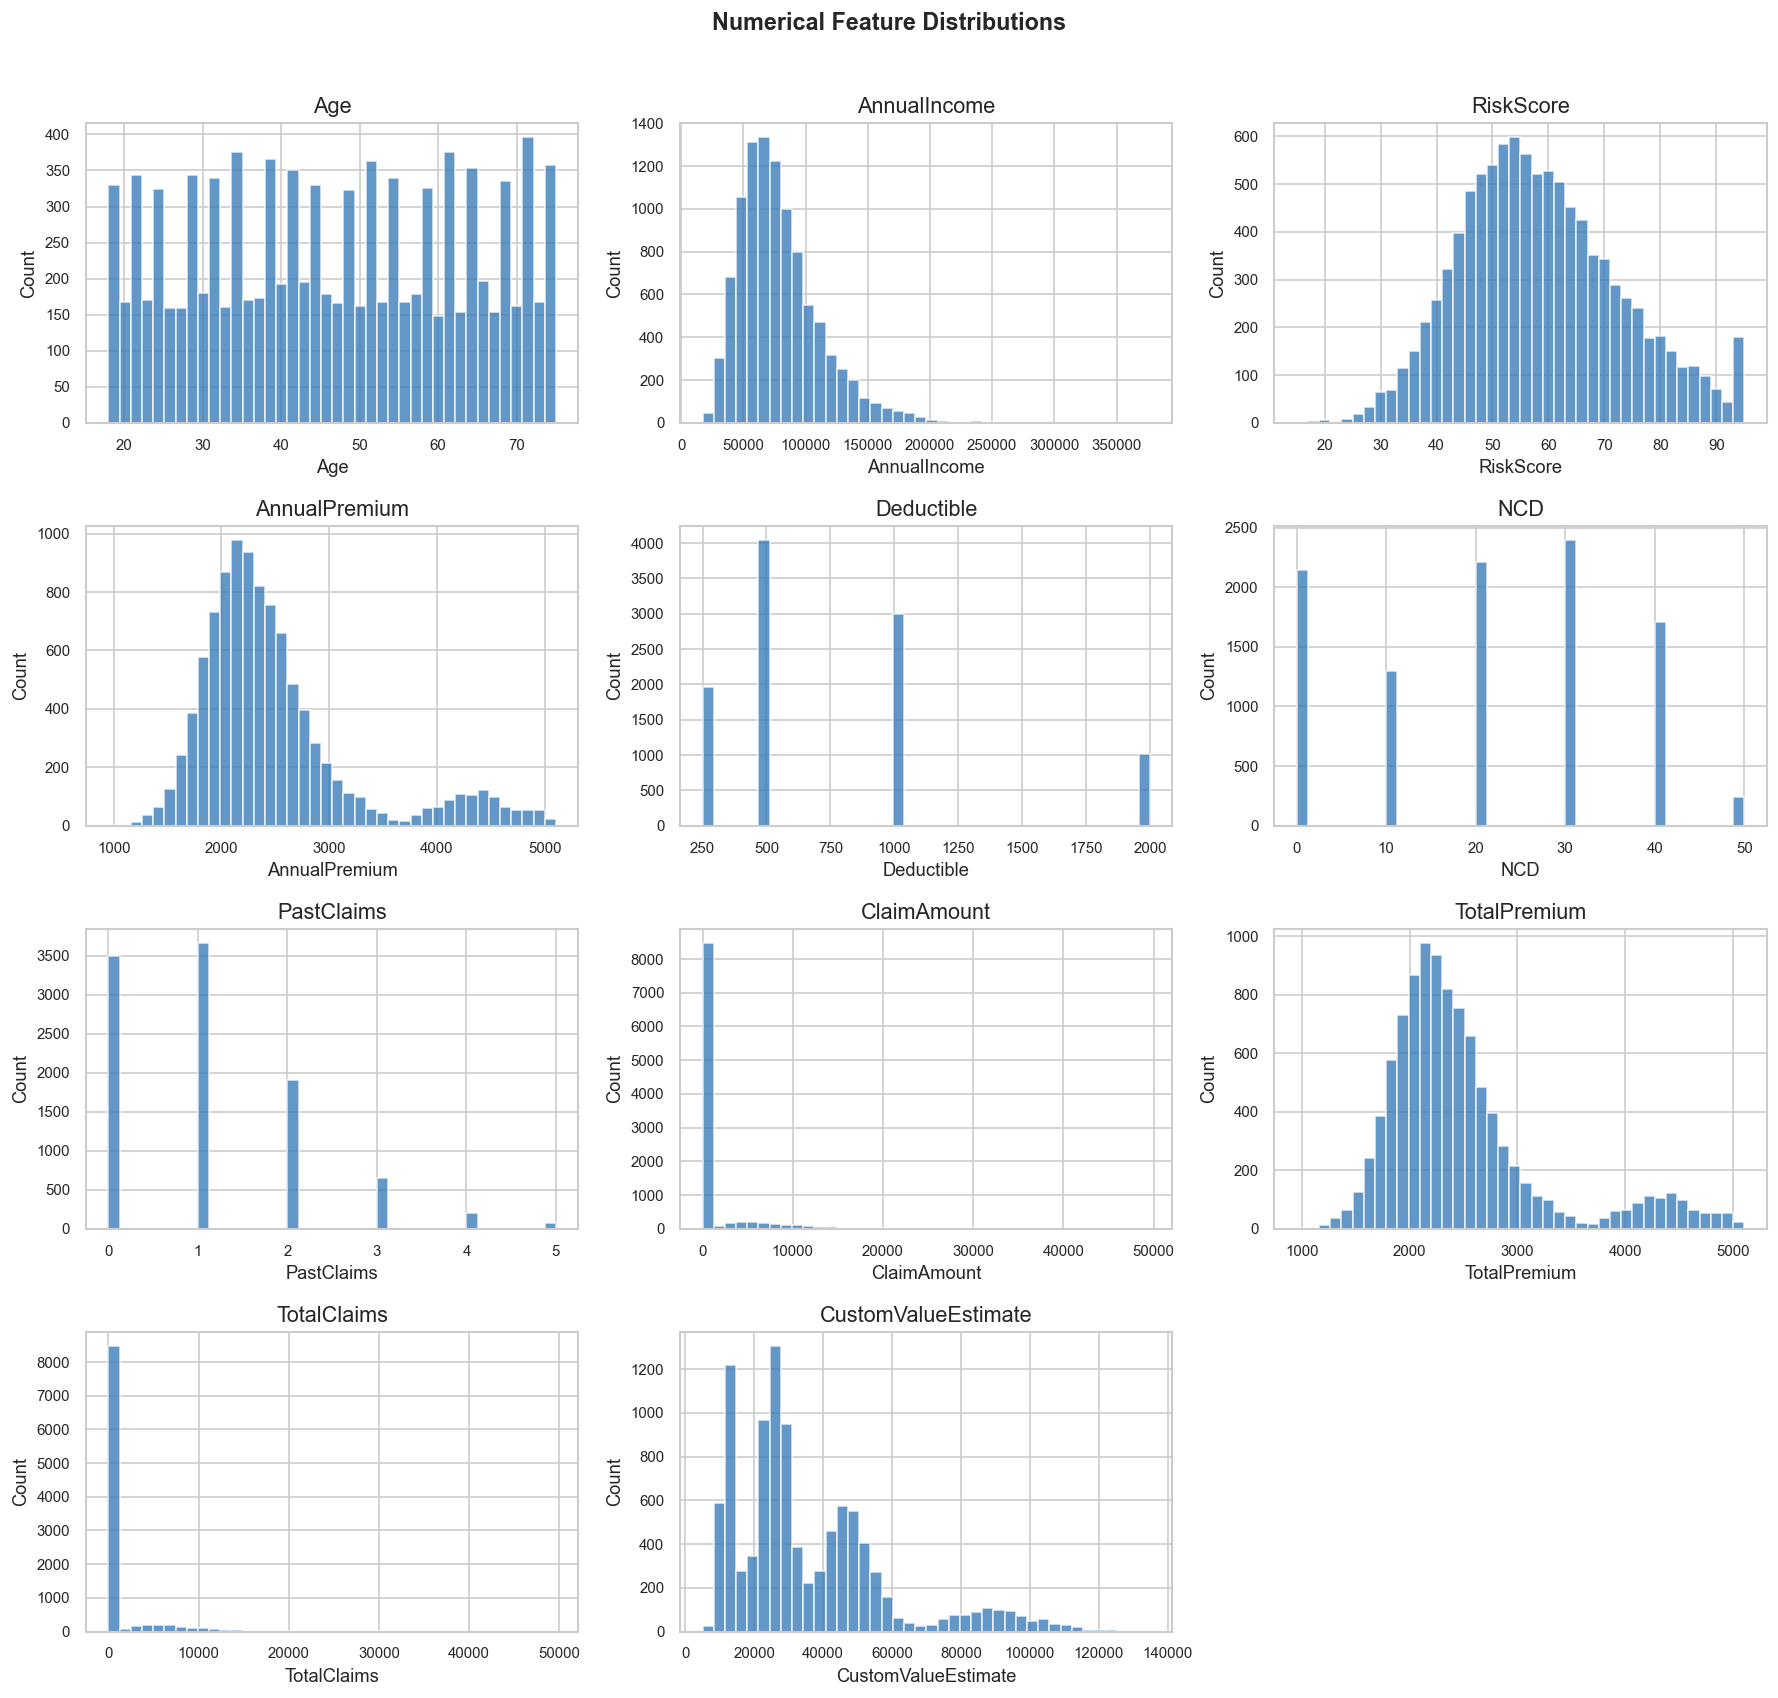

In [19]:
fig = plot_numeric_distributions(df_clean, NUMERIC_COLS, log_scale=False)
plt.savefig('../reports/figures/01_numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 Categorical Distributions

In [ ]:
CAT_COLS = ['Province', 'VehicleType', 'Gender', 'CoverType', 'AutoMake']
fig = plot_categorical_bars(df_clean, CAT_COLS, top_n=10)
plt.savefig('../reports/figures/02_categorical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Bivariate & Multivariate Analysis
### 5.1 TotalPremium vs TotalClaims by Province

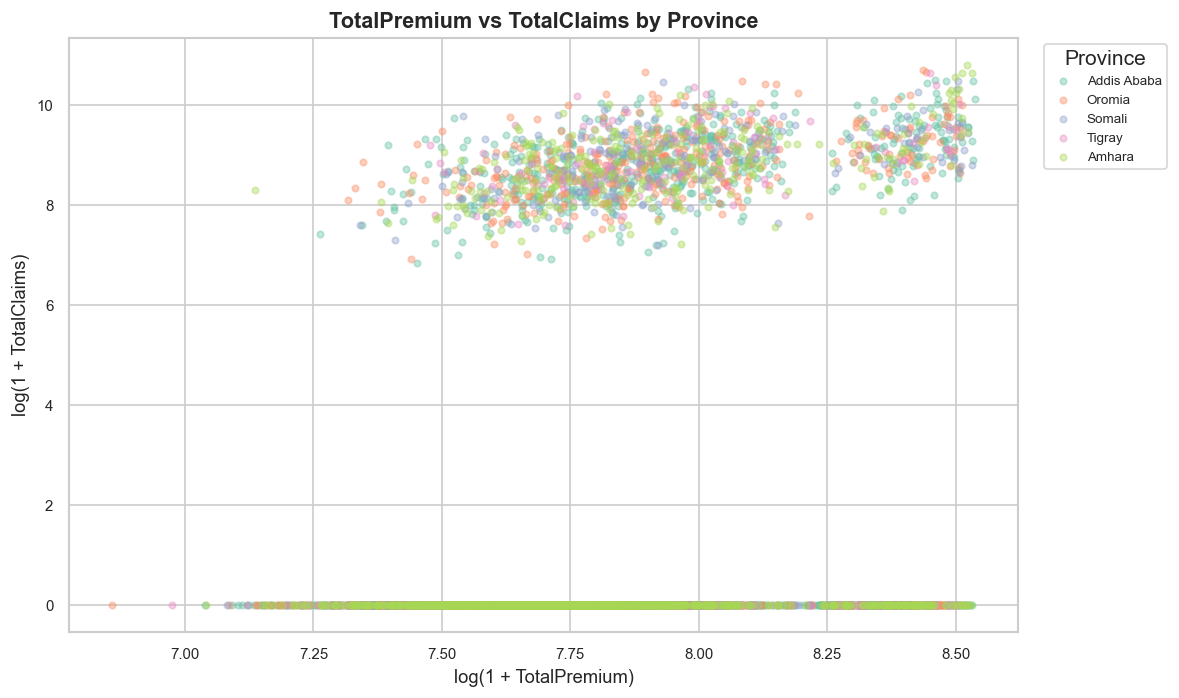

In [20]:
fig = plot_premium_vs_claims(df_clean, hue_col='Province')
plt.savefig('../reports/figures/03_premium_vs_claims_province.png', bbox_inches='tight', dpi=150)
plt.show()

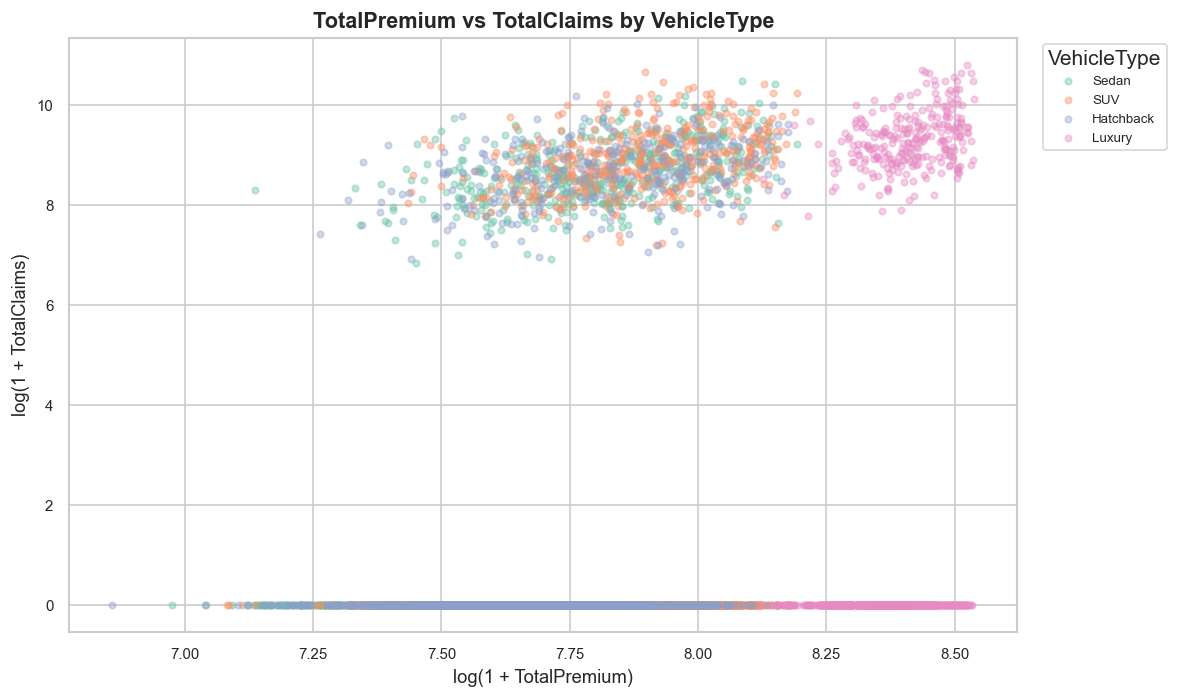

In [22]:
fig = plot_premium_vs_claims(df_clean, hue_col='VehicleType')
plt.show()

### 5.2 Correlation Matrix

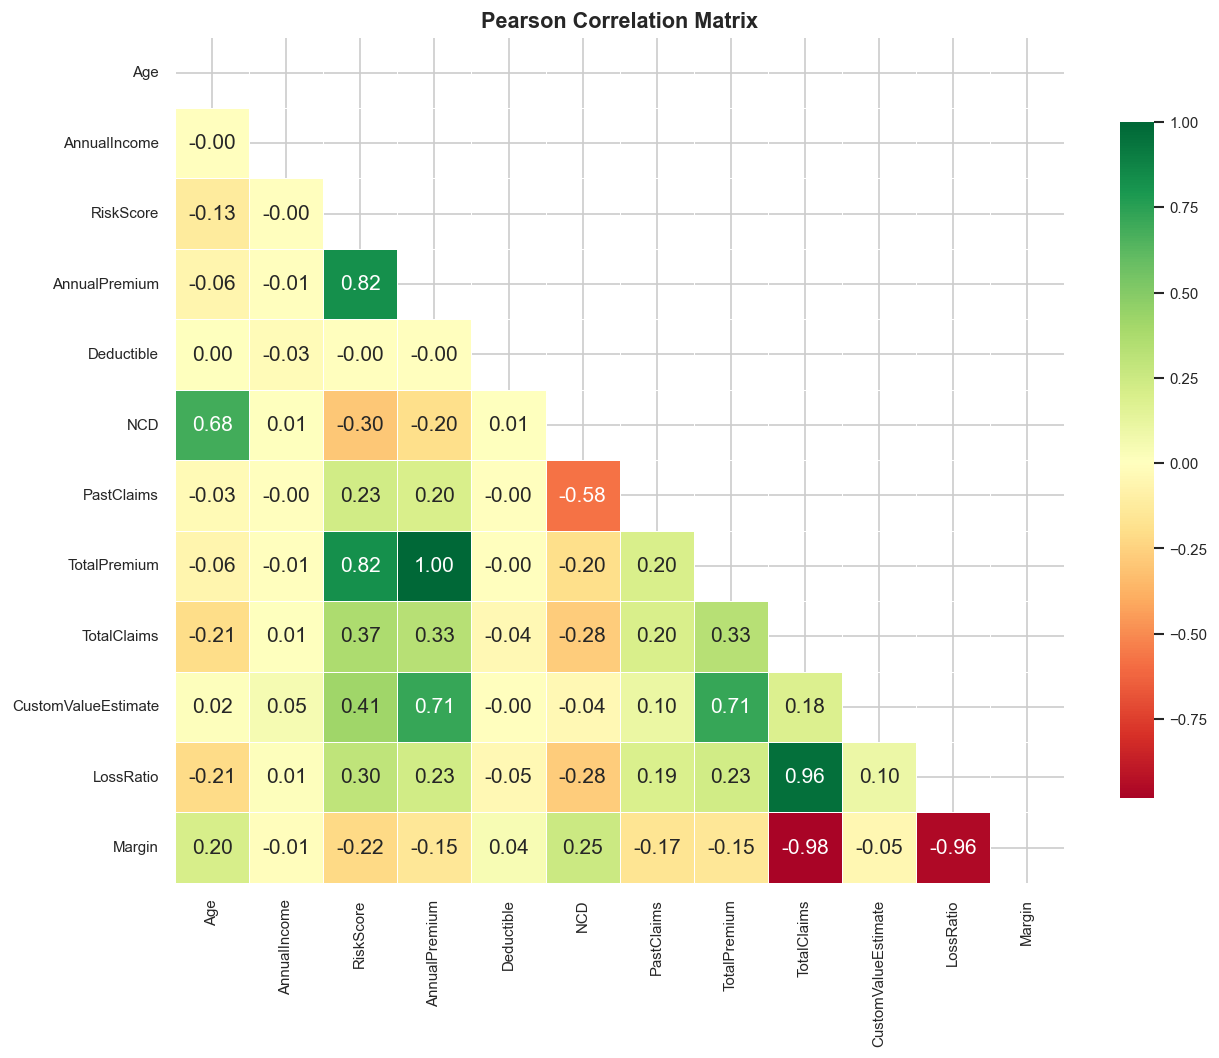

In [21]:
CORR_COLS = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible',
             'NCD', 'PastClaims', 'TotalPremium', 'TotalClaims',
             'CustomValueEstimate', 'LossRatio', 'Margin']

fig = plot_correlation_matrix(df_clean, CORR_COLS)
plt.savefig('../reports/figures/04_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Loss Ratio by ZipCode (Top 20)

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


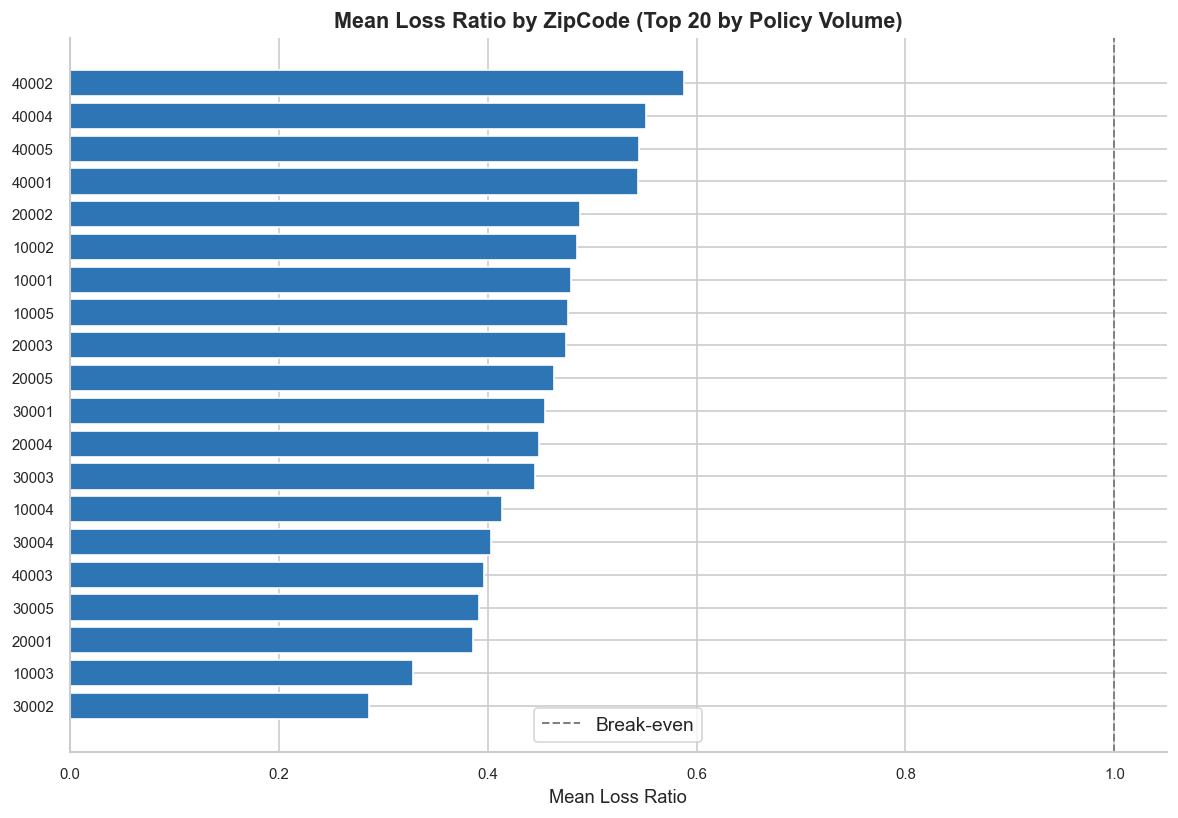

In [23]:
top_zips = df_clean['ZipCode'].value_counts().head(20).index
zip_agg = (
    df_clean[df_clean['ZipCode'].isin(top_zips)]
    .groupby('ZipCode', observed=True)
    .agg(MeanLossRatio=('LossRatio','mean'), PolicyCount=('CustomerID','count'))
    .sort_values('MeanLossRatio', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C00000' if v > 1 else '#2E75B6' for v in zip_agg['MeanLossRatio']]
ax.barh(zip_agg.index.astype(str)[::-1], zip_agg['MeanLossRatio'][::-1], color=colors[::-1])
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even')
ax.set_title('Mean Loss Ratio by ZipCode (Top 20 by Policy Volume)', fontweight='bold')
ax.set_xlabel('Mean Loss Ratio')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/05_loss_ratio_by_zipcode.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Geographic Trends

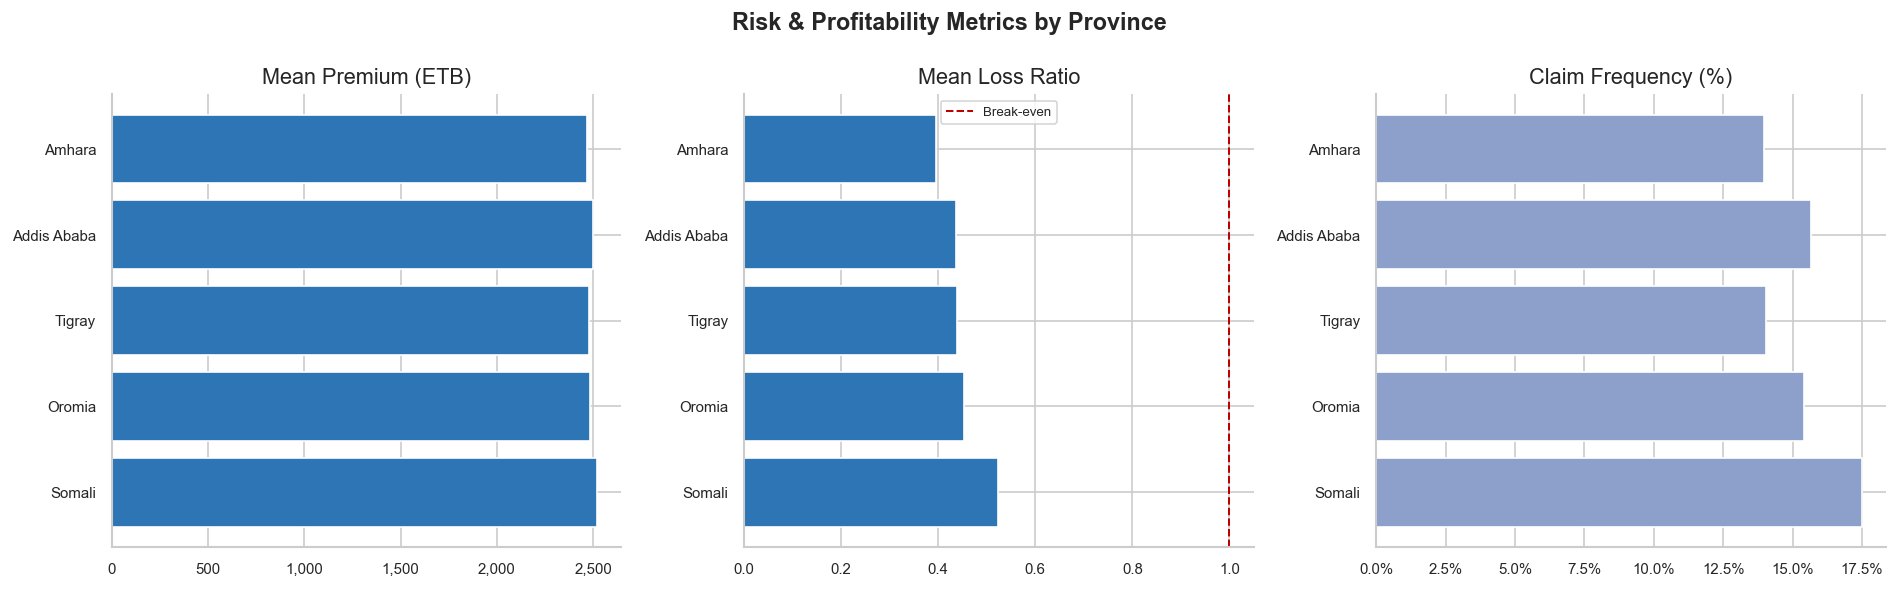

In [24]:
fig = plot_province_metrics(df_clean)
plt.savefig('../reports/figures/06_province_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

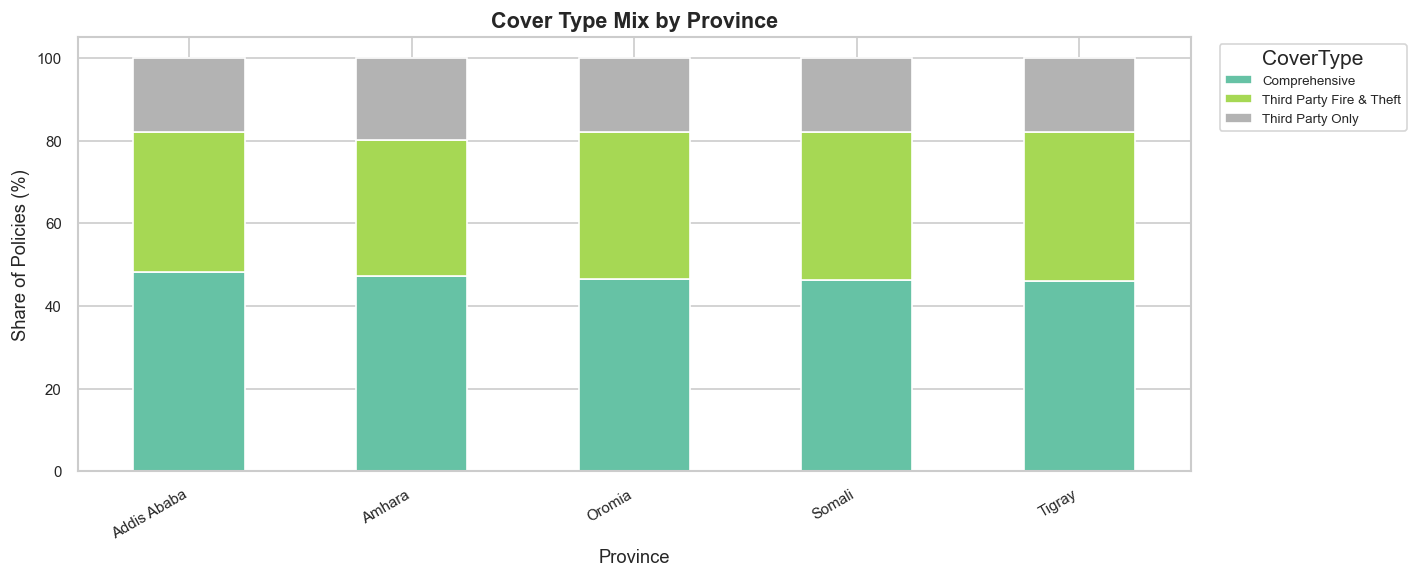

In [25]:
# Cover type mix by province
cover_province = pd.crosstab(df_clean['Province'], df_clean['CoverType'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 5))
cover_province.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Province')
ax.set_ylabel('Share of Policies (%)')
ax.set_title('Cover Type Mix by Province', fontweight='bold')
ax.legend(title='CoverType', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/07_cover_type_by_province.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Outlier Detection

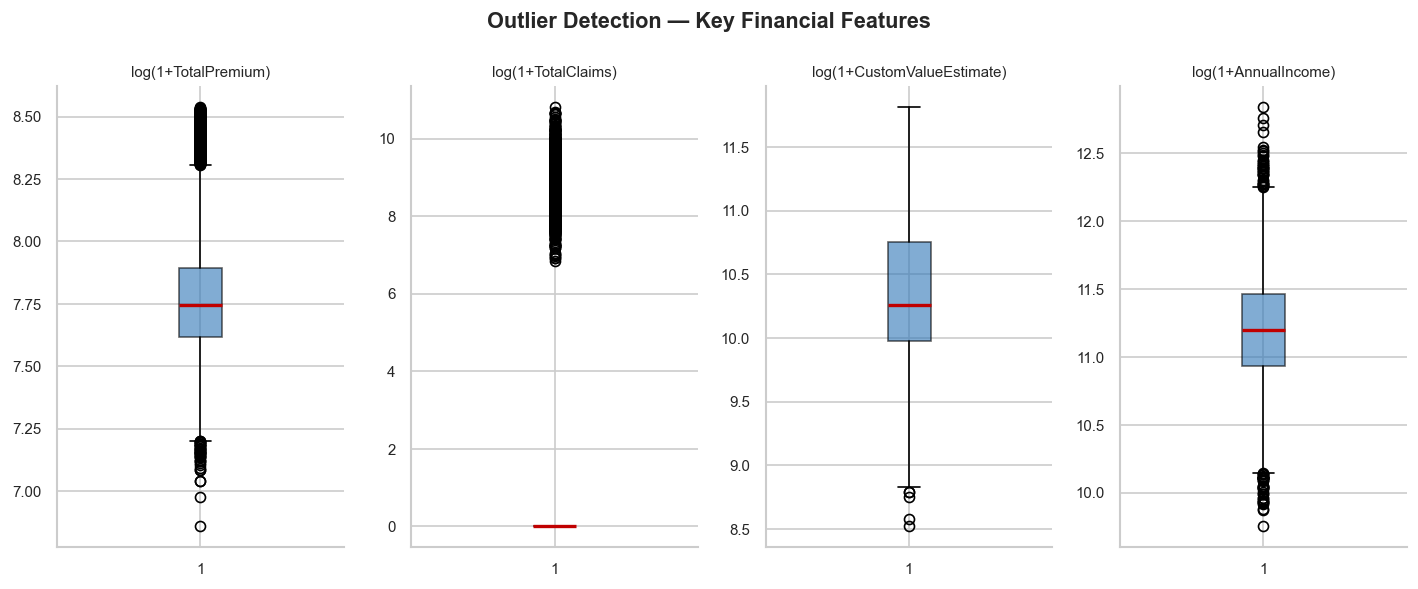

In [26]:
OUTLIER_COLS = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'AnnualIncome']
fig = plot_boxplots(df_clean, OUTLIER_COLS, log_scale=True)
plt.savefig('../reports/figures/08_outlier_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [27]:
outlier_report = {}
for col in OUTLIER_COLS:
    if col not in df_clean.columns: continue
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {'Q1':Q1,'Q3':Q3,'Lower Fence':lower,
                           'Upper Fence':upper,'N Outliers':n_out,
                           'Outlier %':round(n_out/len(df_clean)*100,2)}
pd.DataFrame(outlier_report).T

,Q1,Q3,Lower Fence,Upper Fence,N Outliers,Outlier %
TotalPremium,"2,028.0000","2,676.0000","1,056.0000","3,648.0000",950.0000,9.5000
TotalClaims,0.0000,0.0000,0.0000,0.0000,"1,535.0000",15.3500
CustomValueEstimate,"21,442.7500","46,721.0000","-16,474.6250","84,638.3750",623.0000,6.2300
AnnualIncome,"56,105.0000","95,092.0000","-2,375.5000","153,572.5000",324.0000,3.2400


---
## 8. Guiding Question Answers
### Q1 — Overall Loss Ratio by Province, VehicleType, and Gender

In [28]:
total_premium = df_clean['TotalPremium'].sum()
total_claims  = df_clean['TotalClaims'].sum()
portfolio_lr  = total_claims / total_premium
print(f'Total Premium : {total_premium:>15,.2f} ETB')
print(f'Total Claims  : {total_claims:>15,.2f} ETB')
print(f'Portfolio LR  : {portfolio_lr:.4f}  ({"PROFITABLE" if portfolio_lr < 1 else "UNPROFITABLE"})')

Total Premium :   24,881,279.00 ETB
Total Claims  :   13,141,885.00 ETB
Portfolio LR  : 0.5282  (PROFITABLE)


In [29]:
def lr_breakdown(df, col):
    return (
        df.groupby(col, observed=True)
        .agg(Policies=('CustomerID','count'),
             TotalPremium=('TotalPremium','sum'),
             TotalClaims=('TotalClaims','sum'),
             ClaimFreq=('HasClaim','mean'))
        .assign(LossRatio=lambda x: x['TotalClaims']/x['TotalPremium'])
        .sort_values('LossRatio', ascending=False)
        .round(4)
    )

print('=== By Province ===')
display(lr_breakdown(df_clean, 'Province'))
print('\n=== By VehicleType ===')
display(lr_breakdown(df_clean, 'VehicleType'))
print('\n=== By Gender ===')
display(lr_breakdown(df_clean, 'Gender'))

=== By Province ===


,Policies,TotalPremium,TotalClaims,ClaimFreq,LossRatio
Province,,,,,
Somali,1184,2984984,"1,826,593.0000",0.1748,0.6119
Oromia,2446,6069663,"3,261,061.0000",0.1541,0.5373
Tigray,804,1990692,"1,047,136.0000",0.1405,0.5260
Addis Ababa,3567,8907374,"4,653,210.0000",0.1567,0.5224
Amhara,1999,4928566,"2,353,885.0000",0.1396,0.4776



=== By VehicleType ===


,Policies,TotalPremium,TotalClaims,ClaimFreq,LossRatio
VehicleType,,,,,
Luxury,972,4236839,"3,569,207.0000",0.2840,0.8424
SUV,3000,7256436,"4,090,665.0000",0.1537,0.5637
Hatchback,2036,4532134,"1,904,235.0000",0.1375,0.4202
Sedan,3992,8855870,"3,577,778.0000",0.1298,0.4040



=== By Gender ===


,Policies,TotalPremium,TotalClaims,ClaimFreq,LossRatio
Gender,,,,,
Female,5138,12791141,"6,763,030.0000",0.1538,0.5287
Male,4862,12090138,"6,378,855.0000",0.1532,0.5276


### Q2 — Outliers in TotalClaims and CustomValueEstimate

In [30]:
print('Top 10 Highest Individual Claims:')
display(df_clean.nlargest(10,'TotalClaims')[['CustomerID','Province','VehicleType','AutoMake','TotalPremium','TotalClaims','RiskScore']])

top1 = df_clean['TotalClaims'].quantile(0.99)
top1_sum = df_clean[df_clean['TotalClaims']>top1]['TotalClaims'].sum()
print(f'\nTop 1% of claimants (TotalClaims > {top1:,.0f} ETB) '
      f'account for {top1_sum/total_claims*100:.1f}% of total claim value.')

Top 10 Highest Individual Claims:


,CustomerID,Province,VehicleType,AutoMake,TotalPremium,TotalClaims,RiskScore
9607,AC-109607,Amhara,Luxury,Mercedes-Benz,5029,"49,623.0000",94
4709,AC-104709,Oromia,Luxury,Mercedes-Benz,4614,"44,018.0000",87
5033,AC-105033,Oromia,Luxury,BMW,4640,"42,768.0000",85
129,AC-100129,Oromia,SUV,Hyundai,2686,"42,695.0000",77
3948,AC-103948,Tigray,Luxury,Toyota,4674,"42,148.0000",84
5862,AC-105862,Amhara,Luxury,Mercedes-Benz,4977,"41,860.0000",92
6820,AC-106820,Amhara,Luxury,Toyota,5077,"41,771.0000",95
4965,AC-104965,Amhara,Luxury,Toyota,4907,"38,515.0000",93
9640,AC-109640,Addis Ababa,Luxury,BMW,4723,"36,345.0000",85
8273,AC-108273,Oromia,Sedan,Lifan,3244,"35,975.0000",94



Top 1% of claimants (TotalClaims > 18,607 ETB) account for 19.7% of total claim value.


### Q3 — Temporal Trends

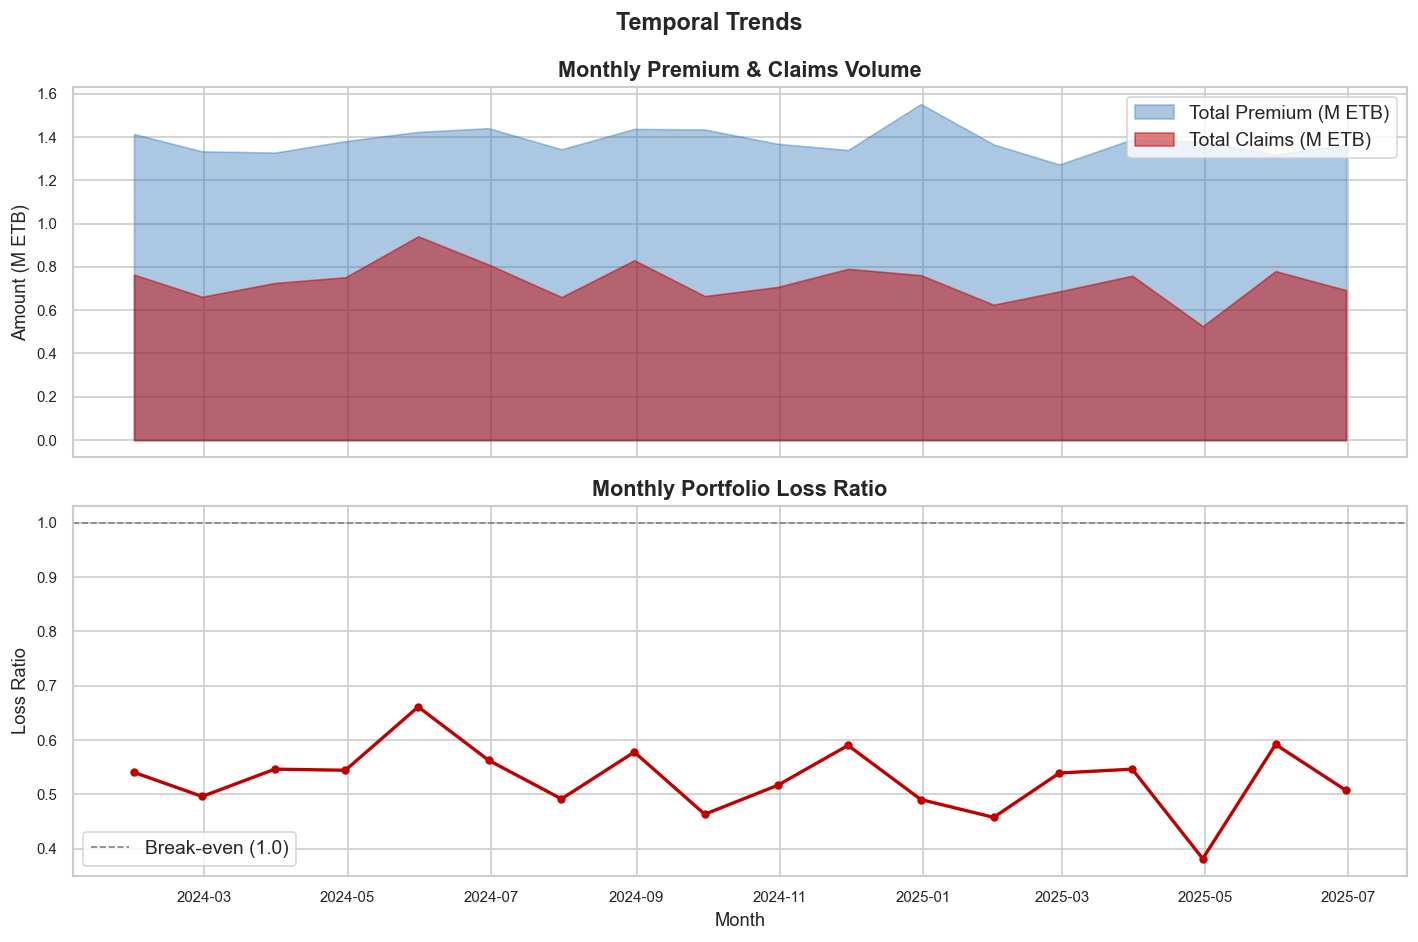

In [31]:
fig = plot_temporal_trends(df_clean)
plt.savefig('../reports/figures/09_temporal_trends.png', bbox_inches='tight', dpi=150)
plt.show()

### Q4 — Vehicle Makes with Highest and Lowest Claim Amounts

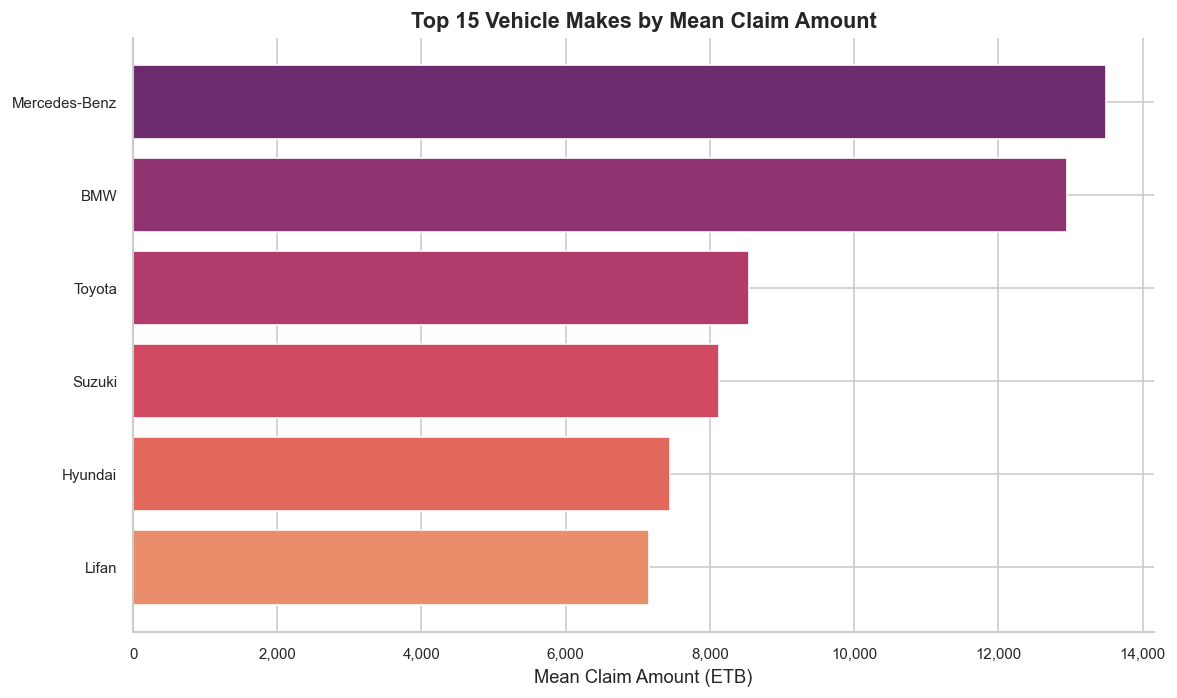

Lowest Mean Claim Makes:


,MeanClaim,Count
AutoMake,,
Lifan,"7,160.0900",164
Hyundai,"7,441.9200",431
Suzuki,"8,120.4200",236
Toyota,"8,545.0500",527
BMW,"12,954.7700",88
Mercedes-Benz,"13,488.5700",89


In [32]:
fig = plot_top_vehicle_makes(df_clean, top_n=15)
plt.savefig('../reports/figures/11_top_vehicle_makes_claims.png', bbox_inches='tight', dpi=150)
plt.show()

lowest = (df_clean[df_clean['TotalClaims']>0]
          .groupby('AutoMake',observed=True)['TotalClaims']
          .agg(['mean','count'])
          .rename(columns={'mean':'MeanClaim','count':'Count'}))
lowest = lowest[lowest['Count']>=5].nsmallest(10,'MeanClaim')
print('Lowest Mean Claim Makes:')
display(lowest.round(2))

---
## 9. Creative Insight Visualizations
### Insight 1 — Loss Ratio Heatmap: Province × VehicleType

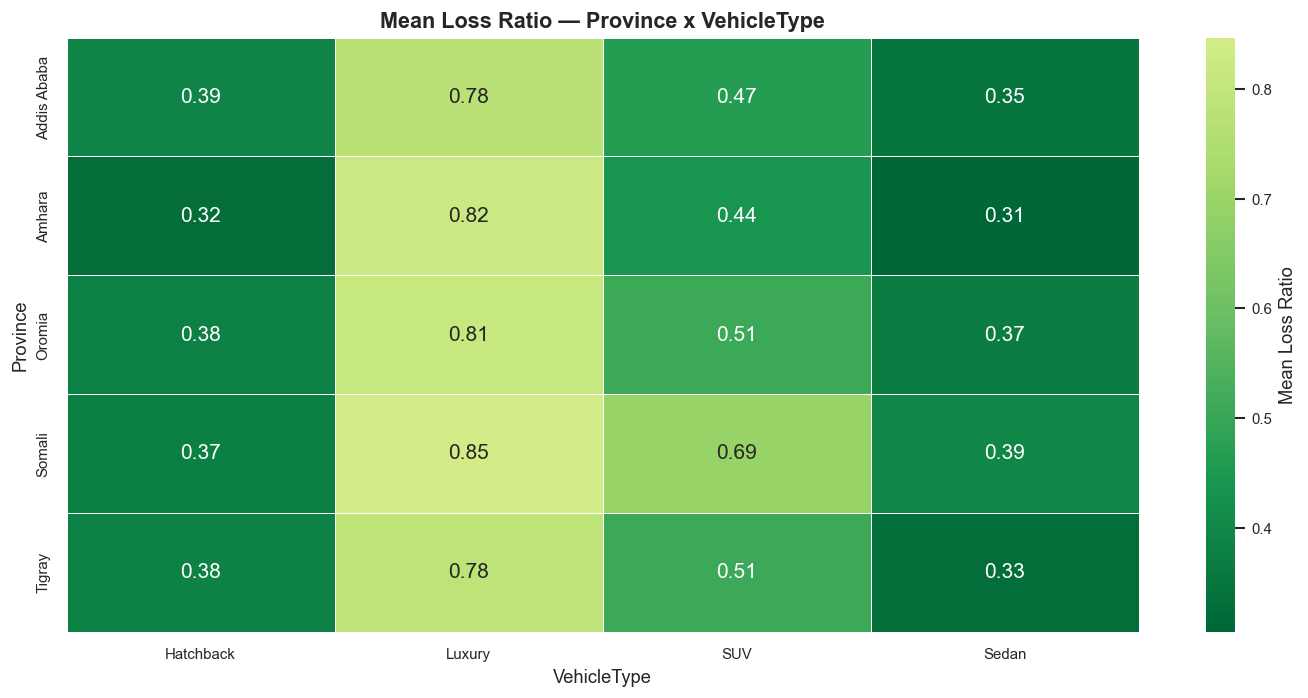

In [33]:
fig = plot_loss_ratio_heatmap(df_clean, row_col='Province', col_col='VehicleType')
plt.savefig('../reports/figures/12_loss_ratio_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Red cells flag province × vehicle-type combinations with loss ratio > 1 — directly actionable for premium repricing.

### Insight 2 — Gender Risk Profile

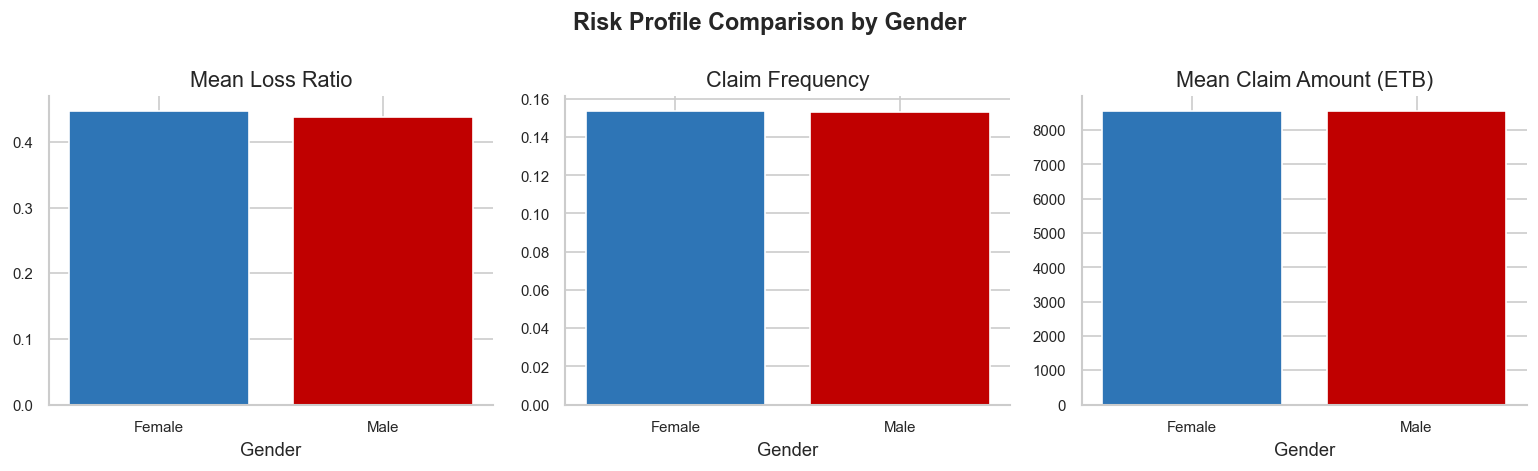

In [34]:
fig = plot_gender_risk(df_clean)
plt.savefig('../reports/figures/13_gender_risk_profile.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Early visual evidence for / against the gender null hypothesis we will formally test in Task 3.

### Insight 3 — Province Risk-Profitability Bubble Chart

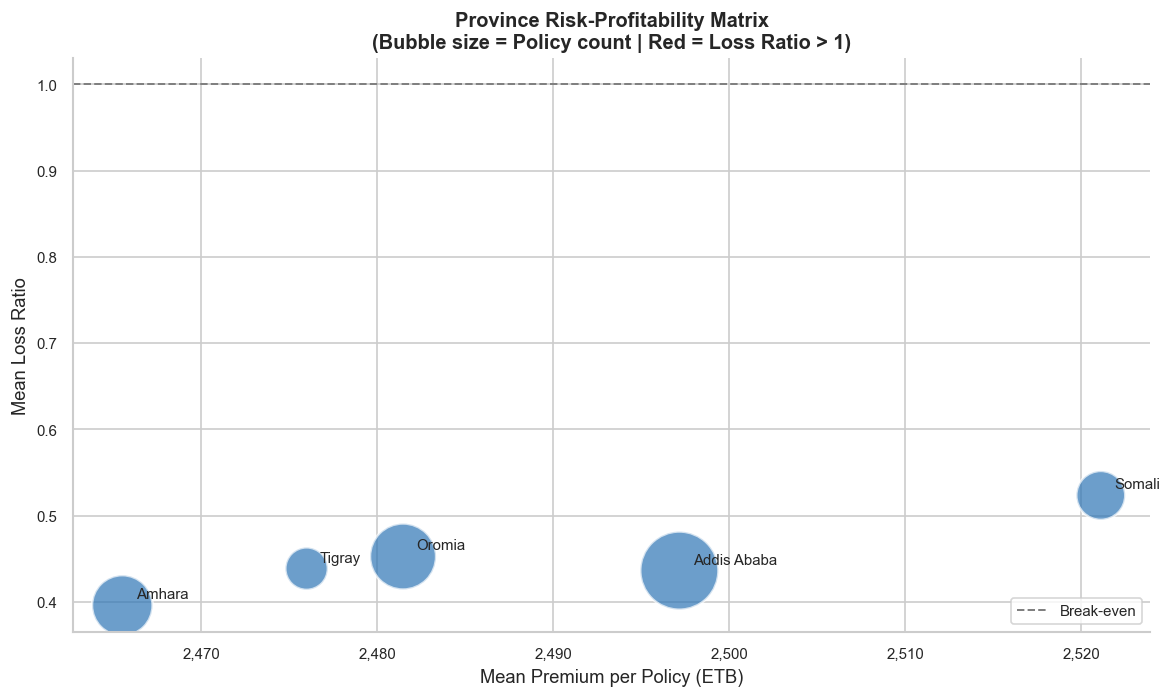

In [35]:
prov_sum = df_clean.groupby('Province',observed=True).agg(
    MeanPremium=('TotalPremium','mean'),
    MeanLossRatio=('LossRatio','mean'),
    PolicyCount=('CustomerID','count')
).reset_index()

fig, ax = plt.subplots(figsize=(10,6))
sizes = (prov_sum['PolicyCount'] / prov_sum['PolicyCount'].max()) * 2000 + 200
colors = ['#C00000' if lr>1 else '#2E75B6' for lr in prov_sum['MeanLossRatio']]
ax.scatter(prov_sum['MeanPremium'], prov_sum['MeanLossRatio'],
           s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidths=1.5)

for _, row in prov_sum.iterrows():
    ax.annotate(row['Province'], (row['MeanPremium'], row['MeanLossRatio']),
                textcoords='offset points', xytext=(8,4), fontsize=9)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even')
ax.set_xlabel('Mean Premium per Policy (ETB)', fontsize=11)
ax.set_ylabel('Mean Loss Ratio', fontsize=11)
ax.set_title('Province Risk-Profitability Matrix\n(Bubble size = Policy count | Red = Loss Ratio > 1)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/14_province_risk_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Positions each province on a profitability-vs-risk plane. Provinces upper-right (high premium + high loss ratio) are revenue contributors but unprofitable — prime candidates for risk-adjusted repricing.

---
## 10. EDA Summary

| Finding | Detail |
|---------|--------|
| Portfolio Loss Ratio | See Q1 output above |
| Highest-risk province | See lr_breakdown output |
| Highest-risk vehicle type | See lr_breakdown output |
| Top 1% claims concentration | See Q2 output |
| Gender risk preview | See Insight 2 — formally tested in Task 3 |

**Next step:** Task 2 — Set up DVC to version the raw and cleaned datasets.